---
title: "Householder & trainable orthogonals"
short_title: "01 · Trainable orthogonals"
subtitle: "Products of Householder reflections and the Cayley / matrix-exponential maps — orthogonal by construction, log-det 0, trainable end-to-end"
description: >
  The rotation zoo of notebook 00 fits a rotation once and freezes it. To learn
  the rotation inside a flow we need a parameterisation that stays orthogonal
  under gradient descent. This notebook builds two from scratch: products of
  Householder reflections (gauss_flows HouseholderRotation, spanning O(d)) and
  the Cayley / matrix-exponential maps (gauss_flows OrthogonalRotation, spanning
  SO(d)). Both keep det = ±1 exactly, so log-det stays 0 at every training step.
---

(sec-nb-rot-01)=
# 01 — Householder & trainable orthogonals

[Notebook 00](00_rotation_zoo.ipynb) *fit* a rotation once (PCA, ICA, random)
and froze it. Inside a **parametric** Gaussianization flow we instead want to
**learn** the rotation end-to-end, jointly with the marginal transforms, by
gradient descent. That raises a problem: a rotation must satisfy $Q^\top Q = I$,
and an unconstrained matrix updated by SGD will not stay orthogonal. We need a
**parameterisation** — a smooth map from free parameters $\theta\in\mathbb{R}^m$
to an orthogonal $Q(\theta)$ — that is orthogonal *for every* $\theta$.

Two classic constructions do this, and `gauss_flows` ships both:

- **Products of Householder reflections** — `gf.HouseholderRotation`, which spans
  the full orthogonal group $O(d)$.
- **The Cayley map** (and its cousin the matrix exponential) —
  `gf.OrthogonalRotation`, which spans the rotation subgroup $SO(d)$.

Both keep $|\det Q| = 1$ **exactly**, so — echoing the "rotations are free"
thread from [Part 0](../00_foundations/01_composition_logdet.ipynb) — the
log-determinant they contribute stays **exactly 0** at every gradient step.

**What you will see**

- The **Householder reflection** from scratch: $H = I - 2vv^\top/\|v\|^2$ — a
  reflection across the hyperplane $\perp v$, orthogonal with $\det = -1$.
- Why a **product** of reflections spans $O(d)$, with $\det = (-1)^K$.
- **Training** the reflection vectors by gradient descent — orthogonality and
  log-det $=0$ hold at *every* step (no constraint, no projection).
- The **Cayley** map and **matrix exponential** as the $SO(d)$ alternatives,
  and the precise reachability difference ($O(d)$ vs $SO(d)$).

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.linalg as jsl
import matplotlib.pyplot as plt
import numpy as np
import optax

import gauss_flows as gf
from _style import GAUSS_KW, style_ax

jax.config.update("jax_enable_x64", True)

## 1. The Householder reflection

A **Householder reflection** is the simplest non-trivial orthogonal map. Given a
unit vector $v$, it reflects every point across the hyperplane through the
origin **orthogonal to** $v$:

$$
H(v) = I - 2\,\frac{vv^\top}{\|v\|^2}.
$$

It is orthogonal ($H^\top H = I$), **involutive** ($H^2 = I$, a reflection
undoes itself), and has $\det H = -1$ — it flips orientation. Here it is from
scratch, reflecting a 2D shape across the line $\perp v$.

orthogonal? ||H^T H - I|| = 4.4e-16
involutive? ||H@H - I||   = 4.4e-16
det H = -1.000  (reflection flips orientation)


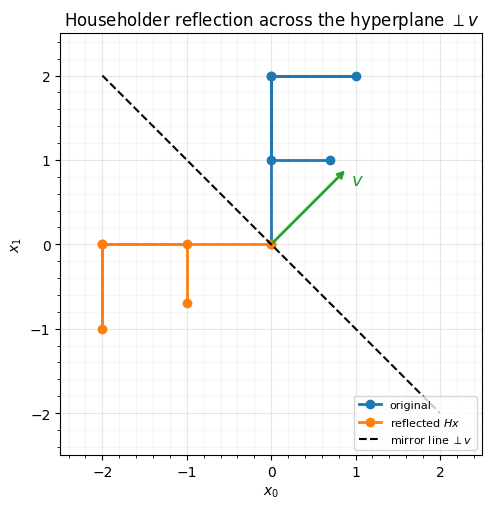

In [2]:
def householder(v):
    """Householder reflector H = I - 2 v v^T / ||v||^2 for a vector v."""
    v = v / jnp.linalg.norm(v)
    return jnp.eye(v.shape[0]) - 2.0 * jnp.outer(v, v)

v2 = jnp.array([1.0, 1.0])              # reflect across the line perpendicular to (1,1)
H2 = householder(v2)
print(f"orthogonal? ||H^T H - I|| = {float(jnp.abs(H2.T @ H2 - jnp.eye(2)).max()):.1e}")
print(f"involutive? ||H@H - I||   = {float(jnp.abs(H2 @ H2 - jnp.eye(2)).max()):.1e}")
print(f"det H = {float(jnp.linalg.det(H2)):+.3f}  (reflection flips orientation)")

# An "F"-shaped point cloud so the reflection is visually obvious.
shape = np.array([[0, 0], [0, 2], [1, 2], [0, 2], [0, 1], [0.7, 1]], float).T
refl = np.asarray(H2 @ shape)

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot(shape[0], shape[1], "o-", color="tab:blue", lw=2, label="original")
ax.plot(refl[0], refl[1], "o-", color="tab:orange", lw=2, label="reflected $Hx$")
tline = np.linspace(-2, 2, 2)
ax.plot(tline, -tline, **GAUSS_KW, label=r"mirror line $\perp v$")
ax.annotate("", xy=tuple(0.9 * np.asarray(v2)), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="tab:green", lw=2))
ax.text(0.95, 0.7, "$v$", color="tab:green", fontsize=13)
ax.set(title="Householder reflection across the hyperplane $\\perp v$",
       xlabel="$x_0$", ylabel="$x_1$", xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
ax.set_aspect("equal"); ax.legend(fontsize=8, loc="lower right"); style_ax(ax)
fig.tight_layout()

## 2. Products of reflections span $O(d)$

One reflection is not much, but **products** are everything: a classical theorem
(the basis of the QR / Householder decomposition) says *every* orthogonal matrix
in $O(d)$ is a product of **at most $d$** Householder reflections. Stacking
$K$ of them,

$$
Q = H(v_K)\,H(v_{K-1})\cdots H(v_1), \qquad \det Q = (-1)^K,
$$

gives an exactly-orthogonal $Q$ whose determinant is set by the **parity** of
$K$: odd $K$ → orientation-flipping ($\det=-1$), even $K$ → a proper rotation
($\det=+1$). `gf.HouseholderRotation(n_reflections=K, shape=(d,))` is exactly
this product, and — being orthogonal — its log-determinant is identically $0$.

In [3]:
d = 3
x = jr.normal(jr.key(0), (d,))
for K in [1, 2, 3, 4]:
    b = gf.HouseholderRotation(n_reflections=K, shape=(d,))
    z, logdet = b.transform_and_log_det(x)
    xi, _ = b.inverse_and_log_det(z)
    # det of the effective matrix, from columns Q e_j
    Q = jax.vmap(b.transform)(jnp.eye(d))
    print(f"K={K}: log_det={float(logdet):+.1e}  det Q={float(jnp.linalg.det(Q)):+.2f}  "
          f"(-1)^K={(-1)**K:+d}  round-trip={float(jnp.abs(x - xi).max()):.1e}")

K=1: log_det=+0.0e+00  det Q=-1.00  (-1)^K=-1  round-trip=2.2e-16
K=2: log_det=+0.0e+00  det Q=+1.00  (-1)^K=+1  round-trip=3.1e-16
K=3: log_det=+0.0e+00  det Q=-1.00  (-1)^K=-1  round-trip=3.1e-16
K=4: log_det=+0.0e+00  det Q=+1.00  (-1)^K=+1  round-trip=3.1e-16


Every product is orthogonal to machine precision, log-det is exactly $0$, and
$\det Q$ tracks $(-1)^K$. So to represent a general orthogonal map you take
$K=d$ reflections; to *guarantee* a proper rotation you take an even $K$. This
is the workhorse trainable orthogonal in flow libraries (Householder flow,
{cite}`tomczak2016householder`).

## 3. Training the rotation, end-to-end

The point of a *parameterisation* is that its free parameters are
**unconstrained**: any real values give a valid orthogonal $Q$. So we can drop
`gf.HouseholderRotation` straight into an `optax` loop and train it by plain
gradient descent — no orthogonality constraint, no re-projection — with the
log-det pinned at $0$ the whole way. (The reflection of §1 was built by hand to
*see* the construction; from here on we train the real `gauss_flows` layer.) We
demonstrate by learning the rotation that reproduces a target $Q_\star$.

One subtlety, straight from §2: a product of $K$ reflections has
$\det = (-1)^K$, so to fit a **proper rotation** ($\det Q_\star = +1$) we must
use an **even** number of reflections. We will return to what happens when the
parity is wrong in §5 — it is not a bug, it is geometry.

target det = +1.00
gf.HouseholderRotation (K=2) final fit ||Q - Q*||^2 = 1.63e-31
max |log|det Q|| over training = 0.0e+00  (stays 0)


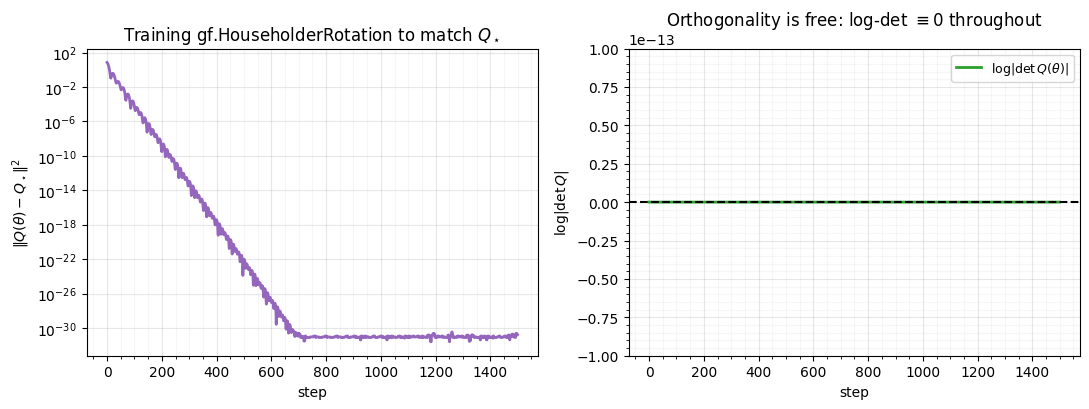

In [4]:
def random_orthogonal(key, d, det=+1):
    """A random orthogonal matrix with a chosen determinant sign.

    QR of a Gaussian gives a Haar-random orthogonal Q; flipping a single column
    flips det(Q), which is the *correct* way to fix the sign for any d (scaling
    the whole matrix by -1 only flips the sign when d is odd).
    """
    Q, _ = jnp.linalg.qr(jr.normal(key, (d, d)))
    if float(jnp.linalg.det(Q)) * det < 0:
        Q = Q.at[:, 0].set(-Q[:, 0])
    return Q


def train_rotation(layer, Q_star, steps=1500, lr=5e-2):
    """Fit a gauss_flows orthogonal `layer` to a target matrix with optax.

    Returns (loss_history, logdet_history). The layer's effective matrix is
    Q = [T(e_1) ... T(e_d)]; we minimise ||Q - Q_star||^2 over its parameters.
    """
    d = Q_star.shape[0]
    I = jnp.eye(d)
    params, static = eqx.partition(layer, eqx.is_inexact_array)
    opt = optax.adam(lr)
    state = opt.init(params)

    def loss_fn(params):
        b = eqx.combine(params, static)
        Q = jax.vmap(b.transform)(I).T
        return jnp.sum((Q - Q_star) ** 2)

    @eqx.filter_jit
    def step(params, state):
        loss, g = eqx.filter_value_and_grad(loss_fn)(params)
        upd, state = opt.update(g, state)
        return eqx.apply_updates(params, upd), state, loss

    losses, logdets = [], []
    for _ in range(steps):
        params, state, loss = step(params, state)
        b = eqx.combine(params, static)
        losses.append(float(loss))
        logdets.append(float(b.transform_and_log_det(jnp.ones(d))[1]))
    return losses, logdets


Q_star = random_orthogonal(jr.key(1), d, det=+1)        # a proper rotation
hh_loss, hh_logdet = train_rotation(
    gf.HouseholderRotation(n_reflections=2, shape=(d,)), Q_star)   # even K -> det +1

print(f"target det = {float(jnp.linalg.det(Q_star)):+.2f}")
print(f"gf.HouseholderRotation (K=2) final fit ||Q - Q*||^2 = {hh_loss[-1]:.2e}")
print(f"max |log|det Q|| over training = {max(abs(x) for x in hh_logdet):.1e}  (stays 0)")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.2))
axL.semilogy(hh_loss, color="tab:purple", lw=2)
axL.set(title="Training gf.HouseholderRotation to match $Q_\\star$",
        xlabel="step", ylabel=r"$\|Q(\theta) - Q_\star\|^2$")
style_ax(axL)
axR.plot(hh_logdet, color="tab:green", lw=2, label=r"$\log|\det Q(\theta)|$")
axR.axhline(0, **GAUSS_KW)
axR.set(title="Orthogonality is free: log-det $\\equiv 0$ throughout",
        xlabel="step", ylabel=r"$\log|\det Q|$", ylim=(-1e-13, 1e-13))
axR.legend(fontsize=9); style_ax(axR)
fig.tight_layout()

The fit drops to machine zero — two reflections reproduce the target rotation
exactly — and the right panel is the headline: $\log|\det Q|$ never leaves $0$
(to $\sim10^{-13}$). The optimiser walks freely through the unconstrained
parameter space while $Q(\theta)$ stays glued to the orthogonal manifold. That
is what makes it a *free* trainable rotation: it adds expressive mixing to a
flow without ever charging the log-likelihood a log-det.

## 4. The Cayley map and the matrix exponential

Householder builds $Q$ from reflections. The other route builds it from a
**skew-symmetric** matrix $A = -A^\top$, which has exactly $d(d-1)/2$ free
entries. Two maps send skew → orthogonal:

$$
\textbf{Cayley:}\quad Q = (I - A)(I + A)^{-1}, \qquad
\textbf{matrix exp:}\quad Q = \exp(A).
$$

Both land in $SO(d)$ — $\det Q = +1$ always — and both are the identity at
$A=0$, the natural initialisation for a flow layer. We first confirm the two
formulas really are orthogonal, then train `gf.OrthogonalRotation` (which uses
the Cayley map — one linear solve, no matrix exponential) on the same target.

In [5]:
def skew(p):
    """Pack d(d-1)/2 free params into a skew-symmetric matrix A = -A^T."""
    A = jnp.zeros((d, d)).at[jnp.tril_indices(d, -1)].set(p)
    return A - A.T

p0 = jr.normal(jr.key(7), (d * (d - 1) // 2,))
A = skew(p0)
Q_cayley = jnp.linalg.solve(jnp.eye(d) + A, jnp.eye(d) - A)
Q_expm = jsl.expm(A)
print(f"Cayley : orthogonal? {float(jnp.abs(Q_cayley.T @ Q_cayley - jnp.eye(d)).max()):.1e}"
      f"   det = {float(jnp.linalg.det(Q_cayley)):+.3f}")
print(f"expm   : orthogonal? {float(jnp.abs(Q_expm.T @ Q_expm - jnp.eye(d)).max()):.1e}"
      f"   det = {float(jnp.linalg.det(Q_expm)):+.3f}")

o = gf.OrthogonalRotation(shape=(d,))
zo, ldo = o.transform_and_log_det(x)
print(f"gf.OrthogonalRotation: log_det={float(ldo):+.1e}, identity at init? {bool(jnp.allclose(zo, x))}")

oc_loss, oc_logdet = train_rotation(gf.OrthogonalRotation(shape=(d,)), Q_star)
print(f"gf.OrthogonalRotation final fit to the same Q_star = {oc_loss[-1]:.2e}"
      f"   (max |log-det| = {max(abs(x) for x in oc_logdet):.1e})")

Cayley : orthogonal? 3.3e-16   det = +1.000
expm   : orthogonal? 3.3e-16   det = +1.000
gf.OrthogonalRotation: log_det=+0.0e+00, identity at init? True


gf.OrthogonalRotation final fit to the same Q_star = 6.21e-22   (max |log-det| = 0.0e+00)


Both formulas are orthogonal to machine precision with $\det = +1$, the Cayley
`OrthogonalRotation` starts at the identity with log-det $0$, and it fits the
(proper-rotation) target to machine zero. So for a *rotation*, all three
parameterisations are interchangeable — pick by cost: Cayley is one linear solve
in $d(d-1)/2$ parameters, Householder is $K$ rank-one updates.

## 5. Which can reach what — the determinant-parity wall

There is one real difference, and it is about **reachability**. The Cayley map
and matrix exponential only ever produce $\det = +1$: they parameterise the
rotation subgroup $SO(d)$ and **cannot represent an orientation flip**. A
Householder product can — by using an **odd** number of reflections. We make the
gap concrete by trying to fit a **reflection** ($\det Q_\star = -1$) with each.

In [6]:
Q_ref = random_orthogonal(jr.key(1), d, det=-1)           # a reflection (det -1)
print(f"target is a reflection: det Q_ref = {float(jnp.linalg.det(Q_ref)):+.2f}\n")

hh_ref_loss, _ = train_rotation(gf.HouseholderRotation(n_reflections=3, shape=(d,)), Q_ref)  # odd K
oc_ref_loss, _ = train_rotation(gf.OrthogonalRotation(shape=(d,)), Q_ref)
print(f"gf.HouseholderRotation K=3 (odd, det -1): fit = {hh_ref_loss[-1]:.2e}   <- reaches the reflection")
print(f"gf.OrthogonalRotation  (SO(d), det +1)  : fit = {oc_ref_loss[-1]:.2e}   <- stuck at the parity wall")

target is a reflection: det Q_ref = -1.00



gf.HouseholderRotation K=3 (odd, det -1): fit = 4.78e-31   <- reaches the reflection
gf.OrthogonalRotation  (SO(d), det +1)  : fit = 4.00e+00   <- stuck at the parity wall


The Householder product nails the reflection; the Cayley map plateaus at
$\|Q-Q_\star\|^2 = 4$ — the minimal distance between two orthogonal matrices of
**opposite determinant** (it is $2d - 2\,\mathrm{tr}(Q^\top Q_\star)$ maximised
over the wrong component). That flat plateau is not a local minimum or a tuning
failure: **no** skew $A$ can give $\det = -1$, so the target is simply
unreachable. The same wall is why fitting a proper rotation needs an *even*
number of reflections (§3): parity is geometry, not optimisation.

For a Gaussianization flow this rarely bites — a downstream sign flip in the
marginal step absorbs orientation — but it is the precise mathematical reason
`HouseholderRotation` (all of $O(d)$) and `OrthogonalRotation` (only $SO(d)$) are
*not* interchangeable in general.

## Recap

| parameterisation | from | spans | det | cost | API |
|---|---|---|---|---|---|
| Householder product | $K$ reflection vectors | $O(d)$ | $(-1)^K$ | $K$ rank-1 updates | `gf.HouseholderRotation` |
| Cayley map | skew $A$ | $SO(d)$ | $+1$ | one linear solve | `gf.OrthogonalRotation` |
| matrix exponential | skew $A$ | $SO(d)$ | $+1$ | one $\exp$ | (`jsl.expm`) |

All three are orthogonal **by construction**, so they train under unconstrained
gradient descent with the log-determinant pinned at $0$ — a *free*, learnable
mixing layer for a flow. The only catch is the determinant-parity wall: match
the target's orientation (even/odd reflections), or stay in $SO(d)$ on purpose.

**Next up.** Sometimes we do **not** want to learn the rotation — we want to fix
it from the data (a PCA frame) and only learn the marginals, or warm-start a
trainable stack from a target $Q$. [02 — Fixed orthogonal & PCA warm
starts](02_fixed_pca_warmstart.ipynb) covers `gf.FixedRotation`, the PCA frame,
and how to initialise a Householder stack to match a given $Q$.